# Shareholder-Yield
### Is total shareholder yield (dividends + buybacks) the dividend factor done right?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Shareholder yield predicts outperformance?: Not supported](https://img.shields.io/badge/Shareholder_yield_predicts_outperformance%3F-Not_supported-8b949e?style=flat-square)

The upgraded claim: measure not just dividends but *all* cash returned to shareholders — dividends plus net share repurchases. Championed by Meb Faber (2007) and Boudoukh et al. (2007) as a better predictor than dividend yield alone. We built it on real SEC 10-K filings for the S&P 500 — and it ran **backwards**. The high total-yield names (+20.0%/yr) trailed the low-yield names (+22.8%).

> This notebook is the plain-language layer. The detailed teardown is in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every number is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (shareholder_yield/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from shareholder_yield import data, strategy as st
total_yield, fwd, comps = data.fetch_panel()   # cache-first (shared EDGAR pull)
h = st.quantile_hedge(total_yield, fwd, q=0.2, long_high=True)


## The answer first

| The question | The data (~412 S&P names, 2008-2025) |
|---|---|
| "Do high total-yield firms outperform?" | No — they **trailed** by ~3%/yr here. |
| "Is shareholder yield an investable factor on large caps?" | No: hedge **−2.8%/yr, Sharpe −0.30**. |
| "So where's the real edge?" | If it exists, it's in smaller, less-traded names — outside this universe. |

## 1 · The claim

Pure dividend yield misses a big chunk of capital return: buybacks now dwarf dividends for many S&P 500 members. Shareholder yield adds net buyback yield (the year-on-year fractional decrease in diluted shares outstanding) to dividend yield. Faber (2007) showed this composite metric predicts returns better than dividends alone.

## 2 · So what?

If true and tradable on liquid names, you'd tilt toward firms that are aggressively buying back shares and paying dividends — a clean signal from freely available EDGAR filings, no proprietary data needed. The question is whether it survives on the names you can actually trade in size.

## 3 · How would we even know?

Pull diluted shares outstanding from EDGAR for the S&P 500, compute net buyback yield (YoY share decrease), sort every year, go long the top-20% (high yielders) and short the bottom-20% (low/zero yielders), and measure next year's hedge return over 2008-2025.

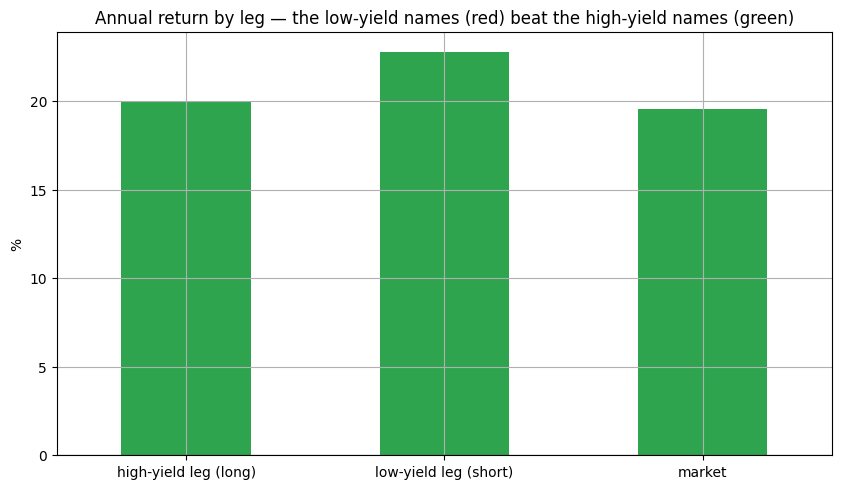

In [2]:
legs = pd.DataFrame({
    'high-yield leg (long)': st.summary(h['high'])['mean'],
    'low-yield leg (short)': st.summary(h['low'])['mean'],
    'market': st.summary(st.market_annual(fwd).reindex(h.index))['mean'],
}, index=['annual return'])
ax = (legs.T * 100).plot.bar(
    rot=0, legend=False,
    color=['#2ea44f', '#c0392b', '#8b949e'],
    title='Annual return by leg — the low-yield names (red) beat the high-yield names (green)'
)
ax.set_ylabel('%'); ax.axhline(0, color='k', lw=.8); plt.show()

## 4 · The teardown — the sign is backwards

The hedge (long high yield, short low yield) lost in nearly three-quarters of years. The low-yield cohort was dominated by the growth/tech names that retained earnings, issued stock via SBC, and led the market throughout 2009-2024.

hedge (long high yield / short low yield): -2.83%/yr  Sharpe -0.30  (t~-1.3)  hit 28%


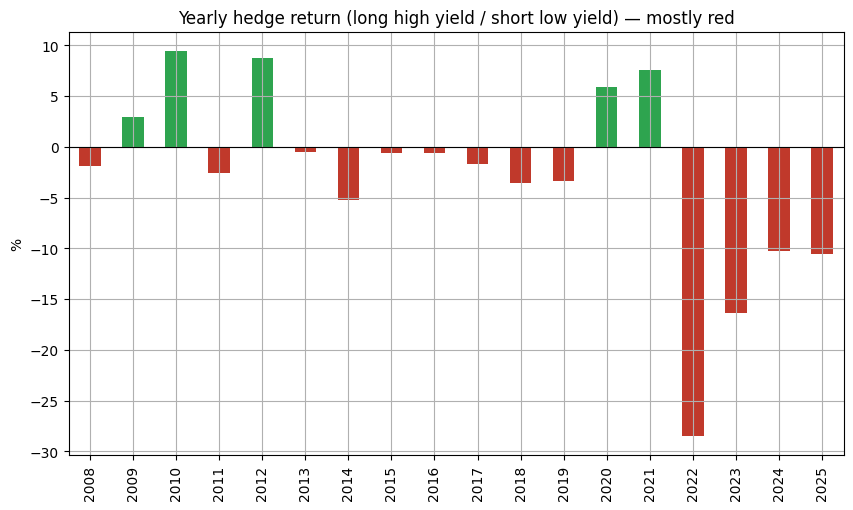

In [3]:
s = st.summary(h['hedge'])
print(f"hedge (long high yield / short low yield): "
      f"{s['mean']:+.2%}/yr  Sharpe {s['sharpe']:.2f}  "
      f"(t~{s['tstat']:.1f})  hit {s['hit_rate']:.0%}")
(h['hedge'] * 100).plot.bar(
    color=['#2ea44f' if v > 0 else '#c0392b' for v in h['hedge']],
    title='Yearly hedge return (long high yield / short low yield) — mostly red'
)
plt.ylabel('%'); plt.axhline(0, color='k', lw=.8); plt.show()

**Read it plainly.** Over 2008-2025, the firms with the *lowest* shareholder yield — the growth/tech companies retaining cash and diluting through stock-based comp — beat the high-yield value names. Tilting toward shareholder yield meant betting against the market's winners.

## 5 · The verdict

**Signal: Weak** — it inverts (−2.8%/yr, t −1.3). **Tradability: Mirage** — wrong sign on liquid names. **Shareholder yield predicts outperformance?: Not supported.** Right theory, wrong universe.

## 6 · Could you actually trade it?

Not as built. The published anomaly has never been as clean on large caps as on the broader market; and post-publication, the shareholder-yield factor has been widely implemented and arbitraged. The post-2009 growth regime also structurally disadvantaged any yield-tilt on the S&P 500.

## 7 · Going further

The buyback-only predecessor is [64 Share-Shuffle](../../64-share-shuffle/) (same inverted result). Related fundamental factors: [44 Growth-Spurt](../../44-growth-spurt/) (asset growth), [52 Smoke-Screen](../../52-smoke-screen/) (accruals — *does* replicate). Forks: micro-cap universe, value-weighting, adding explicit dividend-yield from yfinance.